
# 05 — ML pipeline: baseline vs. scaling versions

**Purposes**: this notebook runs 4 experiments to test the effects of:
- 1. **Feature scaling** on model behaviour, and
- 2. **Temporal reach of the feature set**: the `_Ever` columns, which reach past the index date.


Four runs over one matched frame: **two model versions** (baseline vs. scaling) crossed with **two column sets** (_Ever in vs. out).

| | `_Ever` in | `_Ever` out |
|---|---|---|
| **baseline version** —  no feature scaling | `baseline_with_ever` | `baseline_no_ever` |
| **scaling version** — conventional parameters, `StandardScaler` in a `Pipeline` for the linear models | `scaling_with_ever` | `scaling_no_ever` |

Both versions split cross-validation folds **by matched stratum, never by row**, so a case
and its matched control always land in the same fold.

Both versions build folds the same way — `np.unique(strata)` fed to
`KFold(n_splits=10, shuffle=True, random_state=12345)` — so fold membership is identical
across all four runs and the deltas are comparable in every direction.

Run order: restart and run all. Strip outputs (`nbstripout`) before committing.

# Contents

1. Setup
    1A. Column groups from `config_ml.yaml`
    1B. One-hot encoding and pair integrity
    1C. Cross-validation folds — split on strata, not on rows

2. Column sets: with and without `_Ever`

3. Model versions: baseline vs scaling
    3A. Baseline version — no feature scaling
    3B. Scaling version — conventional parameters, scaled linear models

4. Run all four

5. Reports
    - 5.1 AUC table
    - 5.2 `_Ever` delta, with recall split by class
    - 5.3 ROC curves
6. Baseline vs. scaling — what actually differs
    - 6.1 Convergence warnings
7. Conclusion
    - 7.1 What this does not settle


# 1. Setup

In [1]:
import sys
from pathlib import Path

# make src/ importable whether the notebook is run from notebooks/ or the repo root
_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_ROOT / "src"))

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, roc_auc_score

# package root — shared with the ANN stage in notebook 06
from osteo_pipeline import (
    SEED, N_SPLITS, PROJECT_ROOT, DATA_DIR, SOURCE_FILE, OHE_FILE,
    load_column_groups, make_group_of,
    build_ohe_frame, keep_intact_pairs, split_ever_columns,
    strata_folds, check_pairs_intact, check_frame,
)

# this stage only
from osteo_pipeline.ML import (
    make_model, TRAIN_MODEL_ML, RUN_VERSION,
    REPORT, AUC_TABLE, DELTA_TABLE, TAKEAWAY_TABLE,
    PRED_RATE_TABLE, THRESHOLD_SWEEP,
    PLOT_MULTIPLE_ROC, LABELLED,
)

In [2]:
CONFIG_FILE = Path("config_ml.yaml")     # relative to the notebook's cwd, as before

In [3]:
one = pd.read_csv(SOURCE_FILE, low_memory=False)
print("source:", one.shape)

source: (61026, 203)



## 1A. Column groups from `config_ml.yaml`

- `config_ml.yaml` is the config names of the study's variables.
- For the 2 lab groups in this config file (`calcium_sodium`, `ever_worst`), the models are not fitted on the study variable itself — such as `Calcium_Avg_Ever` — but on **_two columns engineered from it_**:
    - `Calcium_Avg_Ever_decile` (the binned value) and
    - `Calcium_Avg_Ever_measured`(whether the lab was drawn at all).

So two dicts:

- `GROUPS_RAW` — study variable names, as the config writes them. The `_Ever` section below matches on these.
- `GROUPS` — **_engineered column names_**, what the models actually see.

In [4]:
KEYS, GROUPS_RAW, GROUPS = load_column_groups(CONFIG_FILE)

for name, cols in GROUPS_RAW.items():
    print(f"{name}: {cols}")

demographics: ['sex', 'Race_Cat_combine', 'Age_combine']
continuous: ['BMI_Avg']
behavioral: ['Alcohol_Prior', 'Tobacco_Prior']
drugs: ['Drug_antipsych_prior', 'Drug_Estrogens_prior', 'Drug_Glucocorticoids_prior', 'Drug_Nsaids_prior', 'Drug_Opiates_prior', 'Drug_Thiazide_prior', 'Drug_Loop_Diuretic_Prior', 'Drug_Pp_inhibitors_prior', 'Drug_Progesterone_prior', 'Drug_Seizure_prior', 'Drug_Ssris_prior', 'Drug_Tc_antidepress_prior']
diseases: ['HeartDisease_Prior', 'Liver_Prior', 'PulmDisease_Prior', 'CNS_Disease_Prior', 'Malignancy_Prior']
hyponatremia: ['Hyponatremia_Prior', 'Chronic_Hyponatremia', 'Recent_Hyponatremia']
calcium_sodium: ['Calcium_Closest_Osteo', 'Sodium_Closest_Osteo', 'Calcium_Avg_Prior', 'Sodium_Avg_Prior', 'Sodium_Worst_Prior']
ever_worst: ['Calcium_Avg_Ever', 'Sodium_Avg_Ever', 'Sodium_Worst_Ever']


In [5]:
group_of = make_group_of(GROUPS)

## 1B. One-hot encoding and pair integrity

In [6]:
data_OHE, DEMO_COLS, MODEL_COLS = build_ohe_frame(one, KEYS, GROUPS)

In [7]:
data_OHE = keep_intact_pairs(data_OHE)

print("frame        :", data_OHE.shape)
print("strata       :", data_OHE["Strata"].nunique())
print("model columns:", len(MODEL_COLS))
print("demo dummies :", len(DEMO_COLS))
print("by group     :", {name: sum(group_of(c) == name for c in MODEL_COLS)
                         for name in GROUPS})

assert len(data_OHE) == 2 * data_OHE["Strata"].nunique()

frame        : (61026, 51)
strata       : 30513
model columns: 49
demo dummies : 10
by group     : {'demographics': 10, 'continuous': 1, 'behavioral': 2, 'drugs': 12, 'diseases': 5, 'hyponatremia': 3, 'labs_decile': 8, 'labs_measured': 8}


In [8]:
# row-level file, gitignored — nothing downstream of here is committed
data_OHE.to_csv(OHE_FILE, index=False)

In [9]:
MODEL_COLS

['BMI_Avg',
 'Alcohol_Prior',
 'Tobacco_Prior',
 'Drug_antipsych_prior',
 'Drug_Estrogens_prior',
 'Drug_Glucocorticoids_prior',
 'Drug_Nsaids_prior',
 'Drug_Opiates_prior',
 'Drug_Thiazide_prior',
 'Drug_Loop_Diuretic_Prior',
 'Drug_Pp_inhibitors_prior',
 'Drug_Progesterone_prior',
 'Drug_Seizure_prior',
 'Drug_Ssris_prior',
 'Drug_Tc_antidepress_prior',
 'HeartDisease_Prior',
 'Liver_Prior',
 'PulmDisease_Prior',
 'CNS_Disease_Prior',
 'Malignancy_Prior',
 'Hyponatremia_Prior',
 'Chronic_Hyponatremia',
 'Recent_Hyponatremia',
 'Calcium_Closest_Osteo_decile',
 'Sodium_Closest_Osteo_decile',
 'Calcium_Avg_Prior_decile',
 'Sodium_Avg_Prior_decile',
 'Sodium_Worst_Prior_decile',
 'Calcium_Avg_Ever_decile',
 'Sodium_Avg_Ever_decile',
 'Sodium_Worst_Ever_decile',
 'Calcium_Closest_Osteo_measured',
 'Sodium_Closest_Osteo_measured',
 'Calcium_Avg_Prior_measured',
 'Sodium_Avg_Prior_measured',
 'Sodium_Worst_Prior_measured',
 'Calcium_Avg_Ever_measured',
 'Sodium_Avg_Ever_measured',
 'Sodium_


## 1C. Cross-validation folds — split on strata, not on rows

`uniq` and `fold` below are built once and used by **both** versions, so all four runs
see the same 10 folds.

In [10]:
y      = data_OHE["osteo_label"].to_numpy()
strata = data_OHE["Strata"].to_numpy()

uniq, fold = strata_folds(strata)

print("class counts:", np.unique(y, return_counts=True))
print(f"{len(uniq)} strata, {N_SPLITS} folds")

class counts: (array([0, 1]), array([30513, 30513]))
30513 strata, 10 folds


In [11]:
check_pairs_intact(strata, uniq, fold)

print("pairs intact")

pairs intact



# 2. Column sets: with and without `_Ever`

`_Ever` columns span the full record, including the period after the index date.
`_Prior` columns are window-restricted. Everything else — frame, folds, seed, estimator
settings — is held fixed between the two column sets, so the AUC delta is attributable
to these six columns.

In [12]:
EVER_COLS, NO_EVER_COLS = split_ever_columns(MODEL_COLS, GROUPS_RAW)

In [13]:
print(f"MODEL_COLS   : {len(MODEL_COLS)}")
print(f"_Ever matched: {len(EVER_COLS)}")
for col in EVER_COLS:
    print("     ", col)
print(f"NO_EVER_COLS : {len(NO_EVER_COLS)}")

MODEL_COLS   : 49
_Ever matched: 6
      Calcium_Avg_Ever_decile
      Sodium_Avg_Ever_decile
      Sodium_Worst_Ever_decile
      Calcium_Avg_Ever_measured
      Sodium_Avg_Ever_measured
      Sodium_Worst_Ever_measured
NO_EVER_COLS : 43


# 3. Model versions: baseline vs scaling


## 3A. Baseline version — no feature scaling



## 3B. Scaling version — conventional parameters, scaled linear models

`cv_by_strata` reads `data_OHE`, `y`, `strata`, `uniq` and `fold` from the module level.
They are fixed for the whole notebook; only `feature_cols` varies between runs.

# 4. Run all four

In [14]:
BASELINE_MODELS = ['LR', 'RF', 'SVM', 'XGB', 'AdaBoost']
SCALING_MODELS  = ['LR', 'RF', 'SVM', 'XGB']


baseline_with_ever = RUN_VERSION(data_OHE, y, BASELINE_MODELS, MODEL_COLS,   'baseline')
print("baseline_with_ever done")

baseline_with_ever done


In [15]:
baseline_no_ever   = RUN_VERSION(data_OHE, y, BASELINE_MODELS, NO_EVER_COLS, 'baseline')

print("baseline_no_ever done")

baseline_no_ever done


In [16]:
scaling_with_ever  = RUN_VERSION(data_OHE, y, SCALING_MODELS, MODEL_COLS,   'scaling')
print("scaling_with_ever done")

scaling_with_ever done


In [17]:
scaling_no_ever    = RUN_VERSION(data_OHE, y, SCALING_MODELS, NO_EVER_COLS, 'scaling')
print("scaling_no_ever done")

scaling_no_ever done


In [18]:
RUNS = {
    ("baseline", "with_ever"): baseline_with_ever,
    ("baseline", "no_ever"):   baseline_no_ever,
    ("scaling",  "with_ever"): scaling_with_ever,
    ("scaling",  "no_ever"):   scaling_no_ever,
}

In [19]:
print(round(baseline_with_ever.loc["XGB", "AUC"], 6))
print(round(scaling_with_ever.loc["XGB", "AUC"], 6))

0.848178
0.848178


# 5. Reports

In [20]:
for (version, colset), run_df in RUNS.items():
    REPORT(run_df, f"{version} / {colset}", y)

########## baseline / with_ever ##########

===== LR =====
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     30513
           1       0.75      0.67      0.71     30513

    accuracy                           0.72     61026
   macro avg       0.73      0.72      0.72     61026
weighted avg       0.73      0.72      0.72     61026

[[23788  6725]
 [10165 20348]]
AUC           : 0.8075
mean train acc: 0.7234
mean test acc : 0.7232

===== RF =====
              precision    recall  f1-score   support

           0       0.72      0.82      0.77     30513
           1       0.79      0.68      0.73     30513

    accuracy                           0.75     61026
   macro avg       0.76      0.75      0.75     61026
weighted avg       0.76      0.75      0.75     61026

[[25070  5443]
 [ 9698 20815]]
AUC           : 0.8446
mean train acc: 0.8479
mean test acc : 0.7519

===== SVM =====
              precision    recall  f1-score   support



## 5.1 AUC table

Long-to-wide on `colset` only. The two versions are **not** pivoted against each other,
because `XGB` names a different estimator in each and `LR`/`LogReg`, `SVM_linear`/`SVM`
are different parameterisations — aligning them into shared rows would imply a
like-for-like comparison that isn't there.

In [21]:
auc_table = AUC_TABLE(RUNS)

print(auc_table.round(4))

colset             with_ever  no_ever   delta
version  model                               
baseline AdaBoost     0.7504   0.6895 -0.0609
         LR           0.8075   0.7490 -0.0586
         RF           0.8446   0.7886 -0.0560
         SVM          0.8047   0.7405 -0.0642
         XGB          0.8482   0.7900 -0.0582
scaling  LR           0.8076   0.7490 -0.0586
         RF           0.8446   0.7886 -0.0560
         SVM          0.8050   0.7380 -0.0670
         XGB          0.8482   0.7900 -0.0582



## 5.2 `_Ever` delta, with recall split by class

AUC alone hides where the loss lands. Both drivers now return out-of-fold predictions,
so case and control recall are available for all four runs.

In [22]:
delta = pd.concat([
    DELTA_TABLE(baseline_with_ever, baseline_no_ever, "baseline", y),
    DELTA_TABLE(scaling_with_ever,  scaling_no_ever,  "scaling",  y),
])

print(delta.round(4))

                   auc_with_ever  auc_no_ever  auc_delta  \
version  model                                             
baseline LR               0.8075       0.7490    -0.0586   
         RF               0.8446       0.7886    -0.0560   
         SVM              0.8047       0.7405    -0.0642   
         XGB              0.8482       0.7900    -0.0582   
         AdaBoost         0.7504       0.6895    -0.0609   
scaling  LR               0.8076       0.7490    -0.0586   
         RF               0.8446       0.7886    -0.0560   
         SVM              0.8050       0.7380    -0.0670   
         XGB              0.8482       0.7900    -0.0582   

                   case_recall_with_ever  case_recall_no_ever  \
version  model                                                  
baseline LR                       0.6669               0.5431   
         RF                       0.6822               0.5987   
         SVM                      0.6241               0.5167   
         XGB  

In [23]:
PRED_FILE = DATA_DIR / "05_scaling_no_ever_preds.csv"

preds = data_OHE[["Strata", "osteo_label"]].copy()

for name in scaling_no_ever.index:
    row = scaling_no_ever.loc[name]
    preds[f"{name}_prob"] = row["y_prob"]
    preds[f"{name}_pred"] = row["y_pred"]

preds.to_csv(PRED_FILE, index=False)
print(PRED_FILE, preds.shape)

/Users/thanhbrown/Home/work_portfolio/osteo_ml/data/05_scaling_no_ever_preds.csv (61026, 10)


## 5.3 ROC curves

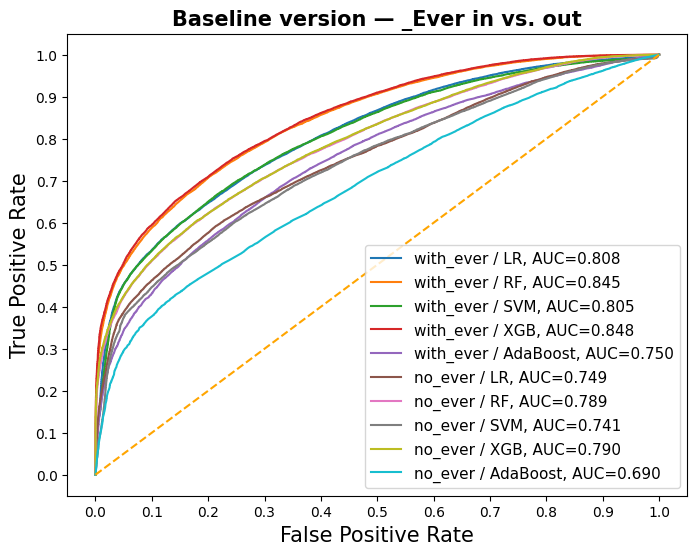

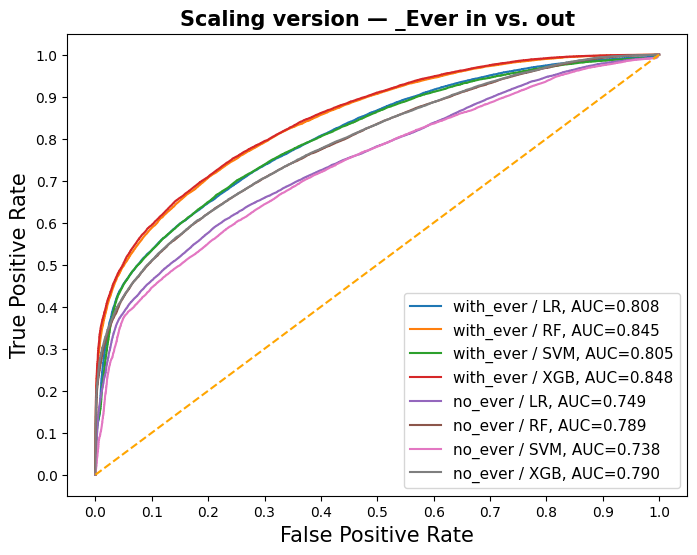

In [24]:
PLOT_MULTIPLE_ROC(LABELLED(RUNS, "baseline"), title="Baseline version — _Ever in vs. out")
PLOT_MULTIPLE_ROC(LABELLED(RUNS, "scaling"),  title="Scaling version — _Ever in vs. out")

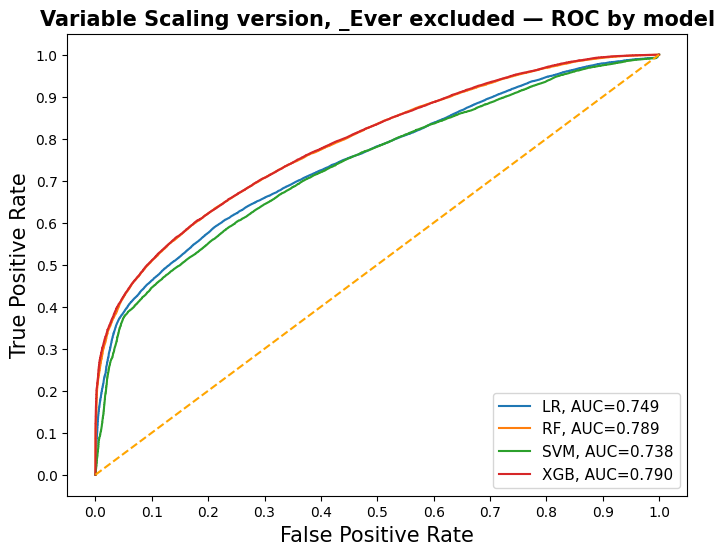

In [25]:
PLOT_MULTIPLE_ROC(
    scaling_no_ever,
    title="Variable Scaling version, _Ever excluded — ROC by model",
    savepath=PROJECT_ROOT / "outputs" / "figures" / "roc_scaling_no_ever.png",
)

## 5.4 Take-away — scaling version, `_Ever` excluded

The defensible run: scaled linear models, `_Ever` columns dropped. AUC and out-of-fold
recall split by class, for the four models in `SCALING_MODELS`. This is the table that
carries to the next notebook.


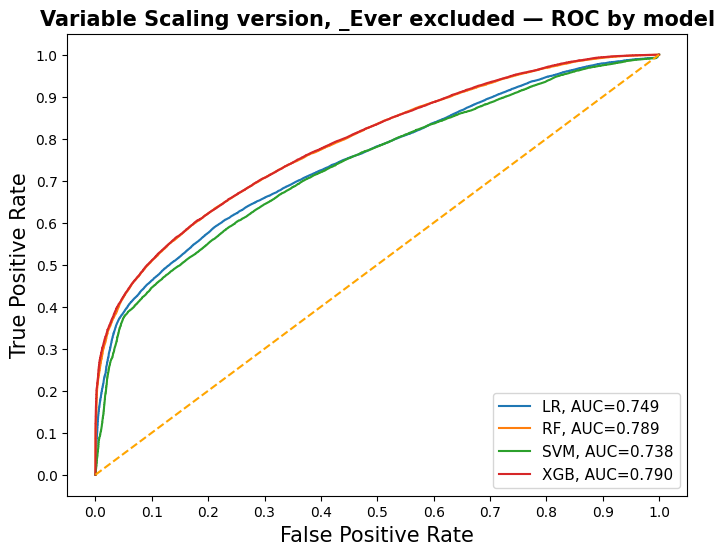

In [26]:
PLOT_MULTIPLE_ROC(
    scaling_no_ever,
    title="Variable Scaling version, _Ever excluded — ROC by model",
    savepath=PROJECT_ROOT / "outputs" / "figures" / "roc_scaling_no_ever.png",
)

In [27]:
scaling_no_ever

,FPR,TPR,AUC,training_acc,testing_acc,y_pred,y_prob
classifier,,,,,,,
LR,"[0.0, 0.0, 0.0, 3.2772916461835936e-05, 3.2772...","[0.0, 3.2772916461835936e-05, 0.00108150624324...",0.749016,"[0.6858635883616766, 0.687356614835585, 0.6867...","[0.6926605504587156, 0.6780799475753604, 0.687...","[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, ...","[0.3880752198775351, 0.38505278127717607, 0.39..."
RF,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 3.2772916461835936e-05, 6.55458329236718...",0.788593,"[0.7860966461527257, 0.7856414551545828, 0.785...","[0.7136304062909568, 0.7024901703800787, 0.711...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0.4114677029694424, 0.366629399351702, 0.4091..."
SVM,"[0.0, 0.0, 0.0, 3.2772916461835936e-05, 3.2772...","[0.0, 3.2772916461835936e-05, 0.00144200832432...",0.737995,"[0.677214959396963, 0.6801645970649285, 0.6728...","[0.6844692005242464, 0.6684141546526867, 0.675...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, ...","[0.3505822663149701, 0.34666551164450454, 0.36..."
XGB,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 3.2772916461835936e-05, 0.00557139579851...",0.789958,"[0.7290521102654673, 0.7291249408251702, 0.728...","[0.7182175622542595, 0.7023263433813892, 0.710...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...","[0.4069128632545471, 0.37380269169807434, 0.40..."


In [28]:
# take-away version: scaling pipeline, _Ever excluded
takeaway = TAKEAWAY_TABLE(scaling_no_ever, y)

print(takeaway.round(4))

          AUC  case_recall  ctrl_recall
model                                  
LR     0.7490       0.5423       0.8300
RF     0.7886       0.5987       0.8242
SVM    0.7380       0.5121       0.8382
XGB    0.7900       0.5927       0.8306


So `recall_score(y, y_pred, pos_label=1)` does one pass over all rows:

- Look only at rows where `y == 1` (the cases).
- Count how many of those have `y_pred == 1`.
- Divide by the total number of cases.

In [29]:
# what fraction of rows does each model call positive, vs. the 0.50 the design implies?
pred_rate = PRED_RATE_TABLE(scaling_no_ever, y)

print("true positive rate in the frame:", round(y.mean(), 4))
print()
print(pred_rate.round(4))

true positive rate in the frame: 0.5

       pred_pos_rate  prob_median  case_recall  ctrl_recall
model                                                      
LR            0.3561       0.4290       0.5423       0.8300
RF            0.3872       0.4302       0.5987       0.8242
SVM           0.3369       0.3924       0.5121       0.8382
XGB           0.3811       0.4187       0.5927       0.8306


In [30]:
# same probabilities, different cutoffs — AUC is fixed, the recalls are not
THRESHOLD_SWEEP(scaling_no_ever, y)


===== LR (AUC 0.7490, fixed) =====
  cut 0.30  case 0.9283  ctrl 0.2408
  cut 0.35  case 0.8873  ctrl 0.3174
  cut 0.40  case 0.7798  ctrl 0.5043
  cut 0.45  case 0.6258  ctrl 0.7462
  cut 0.50  case 0.5423  ctrl 0.8300

===== RF (AUC 0.7886, fixed) =====
  cut 0.30  case 0.9515  ctrl 0.2526
  cut 0.35  case 0.8788  ctrl 0.4191
  cut 0.40  case 0.7543  ctrl 0.6319
  cut 0.45  case 0.6745  ctrl 0.7399
  cut 0.50  case 0.5987  ctrl 0.8242

===== SVM (AUC 0.7380, fixed) =====
  cut 0.30  case 0.9857  ctrl 0.0532
  cut 0.35  case 0.9266  ctrl 0.2218
  cut 0.40  case 0.6442  ctrl 0.6997
  cut 0.45  case 0.5478  ctrl 0.8023
  cut 0.50  case 0.5121  ctrl 0.8382

===== XGB (AUC 0.7900, fixed) =====
  cut 0.30  case 0.9392  ctrl 0.2875
  cut 0.35  case 0.8561  ctrl 0.4621
  cut 0.40  case 0.7374  ctrl 0.6593
  cut 0.45  case 0.6571  ctrl 0.7623
  cut 0.50  case 0.5927  ctrl 0.8306


## 5.5 Export — scaling / `_Ever` excluded, for notebook 08

Everything notebook 08 needs to refit this exact run: the feature list, the estimator
settings, and the fold each stratum was held out in. `05_data_OHE.csv` and
`05_scaling_no_ever_preds.csv` are already written above.


In [31]:
MODEL_DIR = DATA_DIR / "05_models_scaling_no_ever"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

xgb_pred, xgb_prob, xgb_train_acc, xgb_test_acc, xgb_fold_models = TRAIN_MODEL_ML(
    data_OHE, "XGB", NO_EVER_COLS, "scaling", return_models=True
)

payload = {
    "model":        "XGB",
    "version":      "scaling",
    "colset":       "no_ever",
    "feature_cols": NO_EVER_COLS,
    "seed":         SEED,
    "n_splits":     N_SPLITS,
    "fold_models":  xgb_fold_models,
}

path = MODEL_DIR / "XGB.joblib"
joblib.dump(payload, path)

print(path, len(xgb_fold_models), "fits")

/Users/thanhbrown/Home/work_portfolio/osteo_ml/data/05_models_scaling_no_ever/XGB.joblib 10 fits


In [32]:
stored = scaling_no_ever.loc["XGB", "y_prob"]
diff   = np.abs(xgb_prob - stored)

print("max abs diff :", diff.max())
print("exact to 6dp :", (diff < 1e-6).mean())
print("AUC new / old:", round(roc_auc_score(y, xgb_prob), 6),
      "/", round(scaling_no_ever.loc["XGB", "AUC"], 6))

max abs diff : 0.0
exact to 6dp : 1.0
AUC new / old: 0.789958 / 0.789958


# 6. Notes: Baseline vs. scaling — what actually differs

Same frame, same 10 folds, same seed (`12345`). `TRAIN_MODEL_ML` builds folds from
`np.unique(strata)` in both versions, so fold membership is identical and the two
versions are directly comparable.

`make_model` is the only place the versions diverge:

| model | baseline | scaling |
|---|---|---|
| `LR` | `LogisticRegression(solver='liblinear')` | same estimator inside a `Pipeline` with `StandardScaler` |
| `SVM` | `CalibratedClassifierCV(LinearSVC(...))` | same, inside a `Pipeline` with `StandardScaler` |
| `RF` | `n_estimators=300, min_samples_leaf=5` | identical |
| `XGB` | `boost(seed)` | identical |
| `AdaBoost` | baseline only | — |

`RF` and `XGB` are scale-invariant and are passed through unchanged, so their two rows
in the AUC table are the same fit twice — a check that the fold machinery is
deterministic, not a comparison. Only `LR` and `SVM` carry any version signal.

`AdaBoost` has no scaling counterpart and does not appear in the version comparison.

## 6.1 Convergence warnings

`SVM` uses `loss='hinge'` with `dual="auto"` and `max_iter=5000`, which does not converge
on this frame in either version. The warnings are expected but was parameterized so we wont see here. Because the solver stops
early, the small `SVM` differences between versions (third decimal, and in opposite
directions across the two column sets) are solver noise rather than a scaling effect.


# 7. Conclusion

**Scaling vs baseline**: By scaling, I mean applied standardScaler to variables. Tree-based models wont be affected by variable scaling, it's scaling-invariant, while LR and SVM was affect. Based on the results we have, scaling effects here is very small. LR, RF, and XGBoost match to four decimals across versions. Only SVM moves at all, and only in the third decimal — noise from a non-converged solver. Scaling can be dropped as a variable of interest.

**With `_Ever` vs without**: ~0.059 AUC. The drop is uniform across every model family (0.056–0.067), so it reflects signal in the data, not a quirk of any one algorithm. Because _Ever columns span the full record including post-diagnosis time, that signal wouldn't be available at prediction time. The 0.059 is the size of the leak.

The **recall columns** show where the leak was working: dropping _Ever costs 0.08–0.12 in case recall while control recall stays flat or improves.

## 7.1 What this does not settle

- The demographic dummies (`sex_*`, `Race_Cat_combine_*`, `Age_combine_*`) are the
  matching variables and are still in the feature set in all four runs. No drop-column test here — the notebook never refits without them, so it has no number for what they contribute. Meaning I can't say from this notebook whether the matching variables help, hurt, or do nothing — I only have the version where they're in.
- `_Ever` is one candidate column family. `Calcium_Closest_Osteo_*` and
  `Sodium_Closest_Osteo_*` are index-anchored and survive into `NO_EVER_COLS`; they are
  not tested by this notebook.
- No pair-level metric is computed. Every number above is a row-level metric on a
  matched design.